# Suspicious Network Behavior Detection - Notebook Pipeline

**Dataset source**: local `data/` folder  
**Sampling strategy**: 10% sample from each CSV file

## Setup: Import libraries
import all required packages for data handling, visualization, preprocessing, model training, evaluation, and saving artifacts.

In [34]:
import os
import pickle
import warnings
from datetime import datetime

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from collections import Counter
from sklearn.preprocessing import LabelEncoder, RobustScaler
from sklearn.feature_selection import VarianceThreshold, SelectKBest, f_classif
from sklearn.model_selection import train_test_split, StratifiedKFold, GridSearchCV
from sklearn.pipeline import Pipeline
from sklearn.linear_model import LogisticRegression
from sklearn.ensemble import RandomForestClassifier, GradientBoostingClassifier
from sklearn.metrics import (
    classification_report, confusion_matrix, roc_auc_score,
    f1_score, precision_score, recall_score, accuracy_score
)
from imblearn.over_sampling import SMOTE
from xgboost import XGBClassifier

warnings.filterwarnings('ignore')
print('✓ Imports ready')

✓ Imports ready


## Step 1: Load CSV files from `data/` and take 10% sample from each

### Step 1A: Load and sample raw CSV files
This step reads all CSV files from our data folder, takes a reproducible 10% sample from each file, standardizes column names, and merges everything into one combined dataset (`df`).

Why this is done:
- Keeps runtime manageable while preserving data from all traffic scenarios.
- Avoids column-name mismatches caused by extra spaces.
- Produces one unified table for cleaning, EDA, and modeling.

Outputs created in this step:
- `csv_files`: list of detected CSV files
- `df_list`: sampled DataFrames per file
- `df`: final concatenated dataset

In [35]:
data_dir = 'data'
use_full_dataset = False  # True = load full CSVs, False = load sample_frac from each CSV
sample_frac = 0.10
random_state = 42

csv_files = sorted([f for f in os.listdir(data_dir) if f.endswith('.csv')])
print(f'Found {len(csv_files)} CSV files')
print(f"Loading strategy: {'FULL DATASET' if use_full_dataset else f'{int(sample_frac*100)}% SAMPLE'}")

df_list = []
for file_name in csv_files:
    file_path = os.path.join(data_dir, file_name)
    temp_df = pd.read_csv(file_path, low_memory=False)

    if not use_full_dataset:
        temp_df = temp_df.sample(frac=sample_frac, random_state=random_state)

    temp_df.columns = temp_df.columns.str.strip()
    df_list.append(temp_df)

    mode = 'full file' if use_full_dataset else f'{int(sample_frac*100)}% sample'
    print(f'Loaded {mode} from {file_name}: {temp_df.shape}')

df = pd.concat(df_list, axis=0, ignore_index=True)
df.columns = df.columns.str.strip()

print('\nCombined dataset shape:', df.shape)
print('\nLabel distribution:')
print(df['Label'].value_counts())
print('\nMissing values count:', int(df.isnull().sum().sum()))

Found 8 CSV files
Loading strategy: 10% SAMPLE
Loaded 10% sample from Friday-WorkingHours-Afternoon-DDos.pcap_ISCX.csv: (22574, 79)
Loaded 10% sample from Friday-WorkingHours-Afternoon-PortScan.pcap_ISCX.csv: (28647, 79)
Loaded 10% sample from Friday-WorkingHours-Morning.pcap_ISCX.csv: (19103, 79)
Loaded 10% sample from Monday-WorkingHours.pcap_ISCX.csv: (52992, 79)
Loaded 10% sample from Thursday-WorkingHours-Afternoon-Infilteration.pcap_ISCX.csv: (28860, 79)
Loaded 10% sample from Thursday-WorkingHours-Morning-WebAttacks.pcap_ISCX.csv: (17037, 79)
Loaded 10% sample from Tuesday-WorkingHours.pcap_ISCX.csv: (44591, 79)
Loaded 10% sample from Wednesday-workingHours.pcap_ISCX.csv: (69270, 79)

Combined dataset shape: (283074, 79)

Label distribution:
Label
BENIGN                        227282
DoS Hulk                       23051
PortScan                       15889
DDoS                           12917
DoS GoldenEye                   1002
FTP-Patator                      799
SSH-Patator  

## Phase 1: Data Cleaning & Preprocessing

### Step 2A: Handle infinite and missing values


This step prepares the dataset for modeling by fixing problematic values and removing low-quality rows.

What this code does:
- Counts numeric infinite values (`+inf`, `-inf`).
- Replaces infinite values with `NaN`.
- Drops rows with more than 30% missing values.
- Fills remaining numeric missing values using each column median.
- Removes duplicate rows.
- Prints final shape and data-type summary.

Why this is done:
- Prevents model/preprocessing failures caused by invalid numbers.
- Reduces noise from highly incomplete rows.
- Keeps numeric features usable for scaling, selection, and training.

Outputs updated in this step:
- `df` (cleaned dataset)
- `numeric_cols` (numeric columns used for median imputation)

In [36]:
inf_count = np.isinf(df.select_dtypes(include=[np.number])).sum().sum()
print('Infinite values found:', int(inf_count))

df = df.replace([np.inf, -np.inf], np.nan)
before_drop = len(df)
df = df.dropna(thresh=df.shape[1] * 0.7)  #keep rows with <30% missing
print('Rows after dropping >30% NaN:', len(df), '| removed:', before_drop - len(df))

numeric_cols = df.select_dtypes(include=[np.number]).columns
df[numeric_cols] = df[numeric_cols].fillna(df[numeric_cols].median())

before_dedup = len(df)
df = df.drop_duplicates()
print('Rows after dedup:', len(df), '| removed:', before_dedup - len(df))

print('\nShape after cleaning:', df.shape)
print('Data types:\n', df.dtypes.value_counts())

Infinite values found: 444
Rows after dropping >30% NaN: 283074 | removed: 0
Rows after dedup: 269108 | removed: 13966

Shape after cleaning: (269108, 79)
Data types:
 int64      54
float64    24
str         1
Name: count, dtype: int64


## Phase 2: Exploratory Data Analysis (EDA)

### Step 2B: Class distribution and imbalance analysis


compute and visualize the class distribution of `Label`.

- Counts samples per class (`label_counts`).
- Computes the imbalance ratio (largest class ÷ smallest class).



CLASS DISTRIBUTION & IMBALANCE ANALYSIS
Label
BENIGN                        220335
DoS Hulk                       17747
PortScan                       14542
DDoS                           12917
DoS GoldenEye                   1002
FTP-Patator                      651
DoS slowloris                    545
DoS Slowhttptest                 532
SSH-Patator                      415
Bot                              181
Web Attack � Brute Force         166
Web Attack � XSS                  66
Infiltration                       4
Web Attack � Sql Injection         3
Heartbleed                         2
Name: count, dtype: int64

Imbalance ratio (max/min): 110167.50x


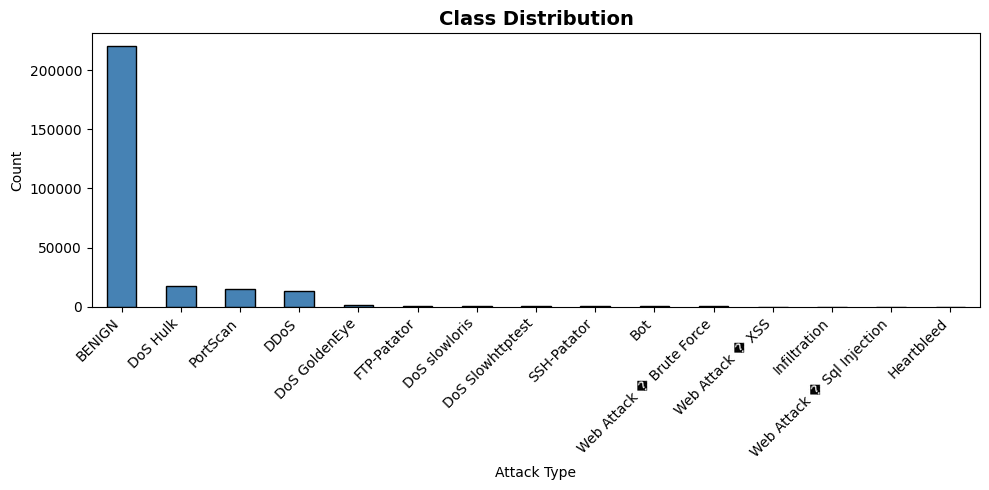


Benign samples: 220335 (81.88%)
Attack samples: 48773 (18.12%)


In [37]:
print('\n' + '='*60)
print('CLASS DISTRIBUTION & IMBALANCE ANALYSIS')
print('='*60)
label_counts = df['Label'].value_counts()
print(label_counts)
print(f'\nImbalance ratio (max/min): {label_counts.max() / label_counts.min():.2f}x')

plt.figure(figsize=(10, 5))
label_counts.plot(kind='bar', color='steelblue', edgecolor='black')
plt.title('Class Distribution', fontsize=14, fontweight='bold')
plt.xlabel('Attack Type')
plt.ylabel('Count')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

benign_count = label_counts.get('BENIGN', 0)
attack_count = len(df) - benign_count
print(f'\nBenign samples: {benign_count} ({benign_count/len(df)*100:.2f}%)')
print(f'Attack samples: {attack_count} ({attack_count/len(df)*100:.2f}%)')



- The dataset is strongly imbalanced: `BENIGN` dominates while some attack classes are very rare.
- High imbalance can make accuracy look strong even when rare attacks are poorly detected.
- For evaluation, prioritize macro metrics and per-class recall (not accuracy alone).
- The imbalance confirms why using SMOTE/adaptive balancing in later steps is important.

### Step 2C: Feature statistics and missing data

#### Quick note
This cell summarizes numeric features after cleaning: it prints descriptive statistics, checks remaining missing values, and detects zero-variance columns that may be uninformative for modeling.

In [38]:
numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
print(f'\n{len(numeric_cols)} Numeric Features')
print('\nDescriptive Statistics:')
print(df[numeric_cols].describe().round(3))

print(f'\n\nMissing values (after cleaning):')
missing = df[numeric_cols].isnull().sum()
if missing.sum() > 0:
    print(missing[missing > 0].sort_values(ascending=False))
else:
    print('✓ None')

print(f'\n\nZero-variance features:')
zero_var = df[numeric_cols].var() == 0
if zero_var.sum() > 0:
    print(df[numeric_cols].loc[:, zero_var].columns.tolist())
else:
    print('✓ None')



78 Numeric Features

Descriptive Statistics:
       Destination Port  Flow Duration  Total Fwd Packets  \
count        269108.000   2.691080e+05         269108.000   
mean           8471.564   1.546040e+07              9.243   
std           18702.999   3.425313e+07            698.857   
min               0.000  -1.000000e+00              1.000   
25%              53.000   1.770000e+02              1.000   
50%              80.000   4.400250e+04              2.000   
75%             443.000   4.624140e+06              5.000   
max           65532.000   1.200000e+08         193200.000   

       Total Backward Packets  Total Length of Fwd Packets  \
count              269108.000                   269108.000   
mean                   10.216                      560.576   
std                   921.530                     5290.635   
min                     0.000                        0.000   
25%                     1.000                       12.000   
50%                     2.000   

### Step 2D: Feature distributions (top 12 highest-variance features)


This cell plots histograms for the 12 numeric features with the highest variance to inspect their value distributions. It helps identify strong right-skew and extreme outliers, so we can decide whether transformations like `log1p` are needed before scaling and model training.

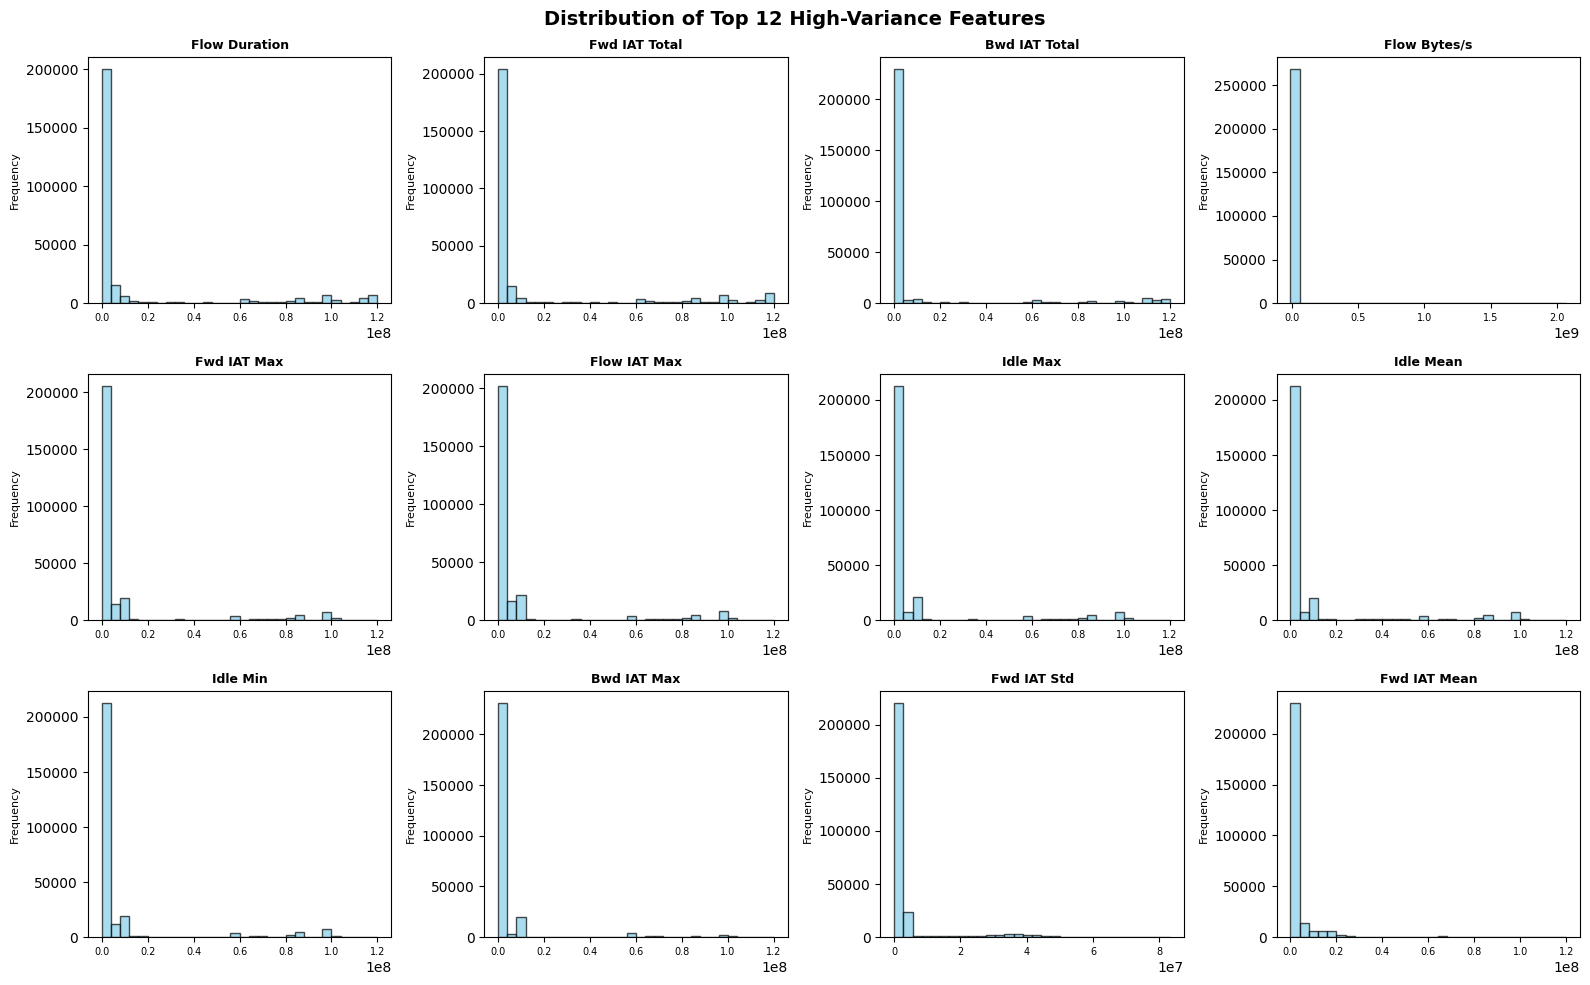

Visualized 12 features with highest variance


In [39]:
top_features = df[numeric_cols].var().nlargest(12).index.tolist()

fig, axes = plt.subplots(3, 4, figsize=(16, 10))
axes = axes.flatten()

for idx, col in enumerate(top_features):
    axes[idx].hist(df[col].dropna(), bins=30, color='skyblue', edgecolor='black', alpha=0.7)
    axes[idx].set_title(f'{col[:20]}', fontsize=9, fontweight='bold')
    axes[idx].set_ylabel('Frequency', fontsize=8)
    axes[idx].tick_params(axis='x', labelsize=7)

fig.suptitle('Distribution of Top 12 High-Variance Features', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print(f'Visualized {len(top_features)} features with highest variance')


### Step 2E: Correlation analysis

 computes the correlation matrix for numeric features and visualizes it as a heatmap to show which features move together. It also prints the strongest feature pairs with absolute correlation above 0.9, which helps detect redundancy and supports later feature selection decisions.

Calculating correlation matrix (may take a moment)...


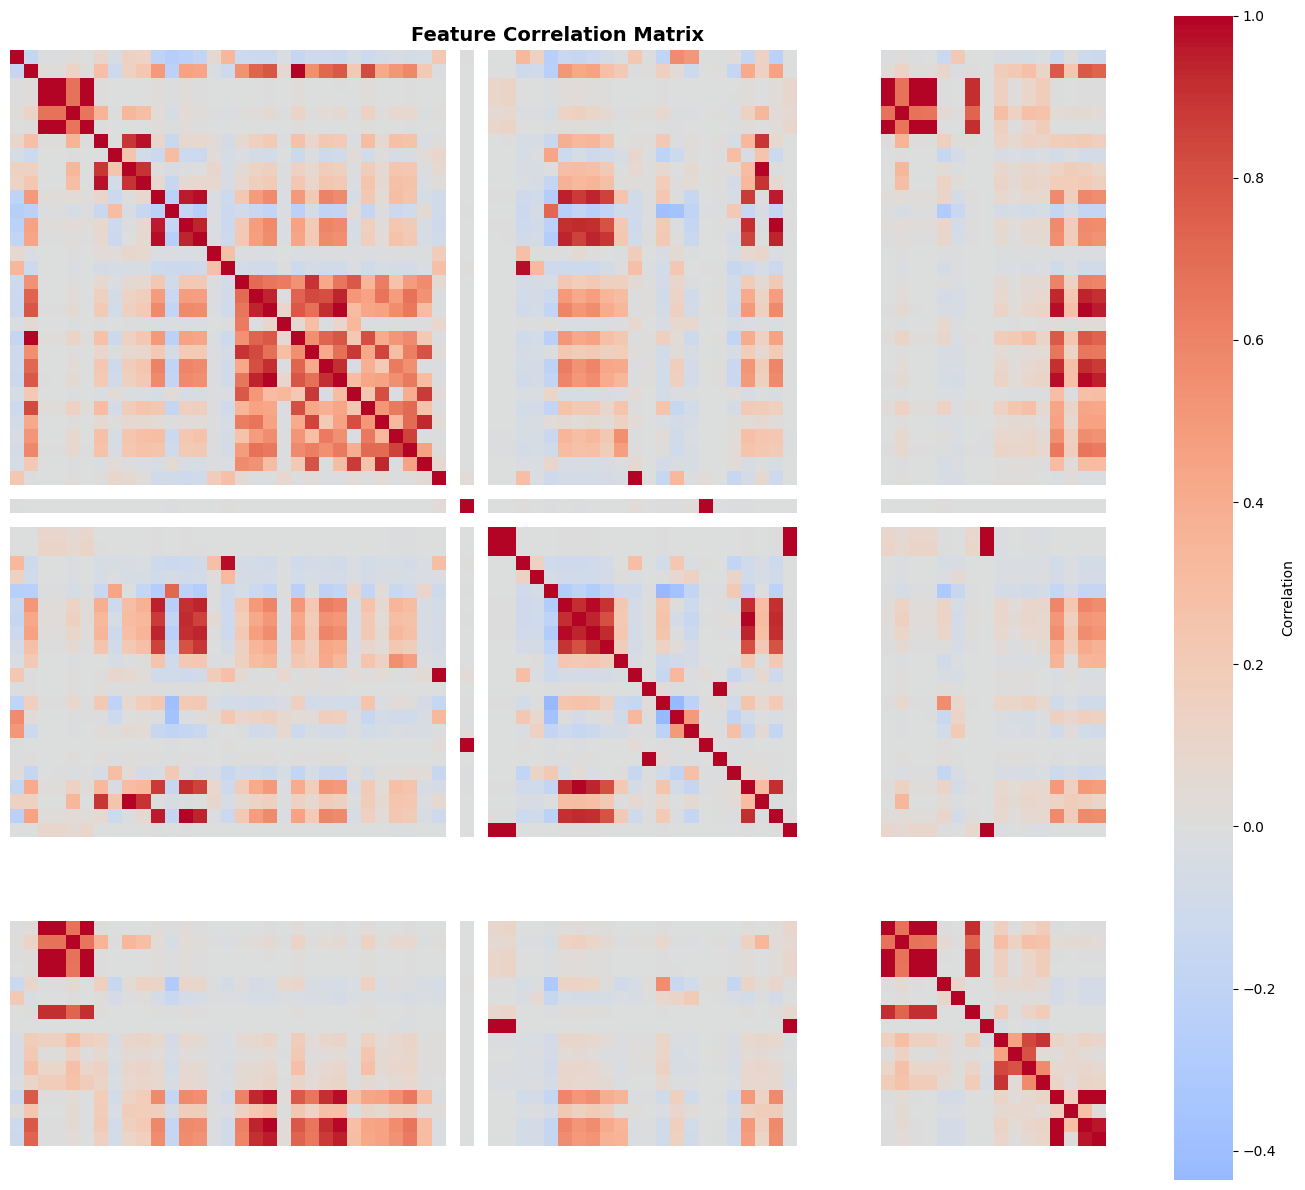


Highly correlated feature pairs (|corr| > 0.9):
  Total Fwd Packets    <-> Subflow Fwd Packets : +1.000
  Total Backward Packe <-> Subflow Bwd Packets : +1.000
  Total Length of Fwd  <-> Subflow Fwd Bytes   : +1.000
  Fwd Packet Length Me <-> Avg Fwd Segment Size: +1.000
  Bwd Packet Length Me <-> Avg Bwd Segment Size: +1.000
  Fwd PSH Flags        <-> SYN Flag Count      : +1.000
  Fwd URG Flags        <-> CWE Flag Count      : +1.000
  Fwd Header Length    <-> Fwd Header Length.1 : +1.000
  RST Flag Count       <-> ECE Flag Count      : +1.000
  Total Length of Bwd  <-> Subflow Bwd Bytes   : +1.000


In [40]:
print('Calculating correlation matrix (may take a moment)...')
corr_matrix = df[numeric_cols].corr()

plt.figure(figsize=(14, 12))
sns.heatmap(corr_matrix, cmap='coolwarm', center=0, square=True, 
            xticklabels=False, yticklabels=False, cbar_kws={'label': 'Correlation'})
plt.title('Feature Correlation Matrix', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('\nHighly correlated feature pairs (|corr| > 0.9):')
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        if abs(corr_matrix.iloc[i, j]) > 0.9:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], corr_matrix.iloc[i, j]))

if high_corr_pairs:
    for feat1, feat2, corr_val in sorted(high_corr_pairs, key=lambda x: abs(x[2]), reverse=True)[:10]:
        print(f'  {feat1[:20]:20s} <-> {feat2[:20]:20s}: {corr_val:+.3f}')
else:
    print('  ✓ None found')


### Step 2F: Outlier detection via boxplots

draws boxplots for the 8 highest-variance numeric features to quickly spot spread and potential outliers. It helps us decide whether to keep extremes, apply robust scaling, or use transformations (for example `log1p`) before model training.

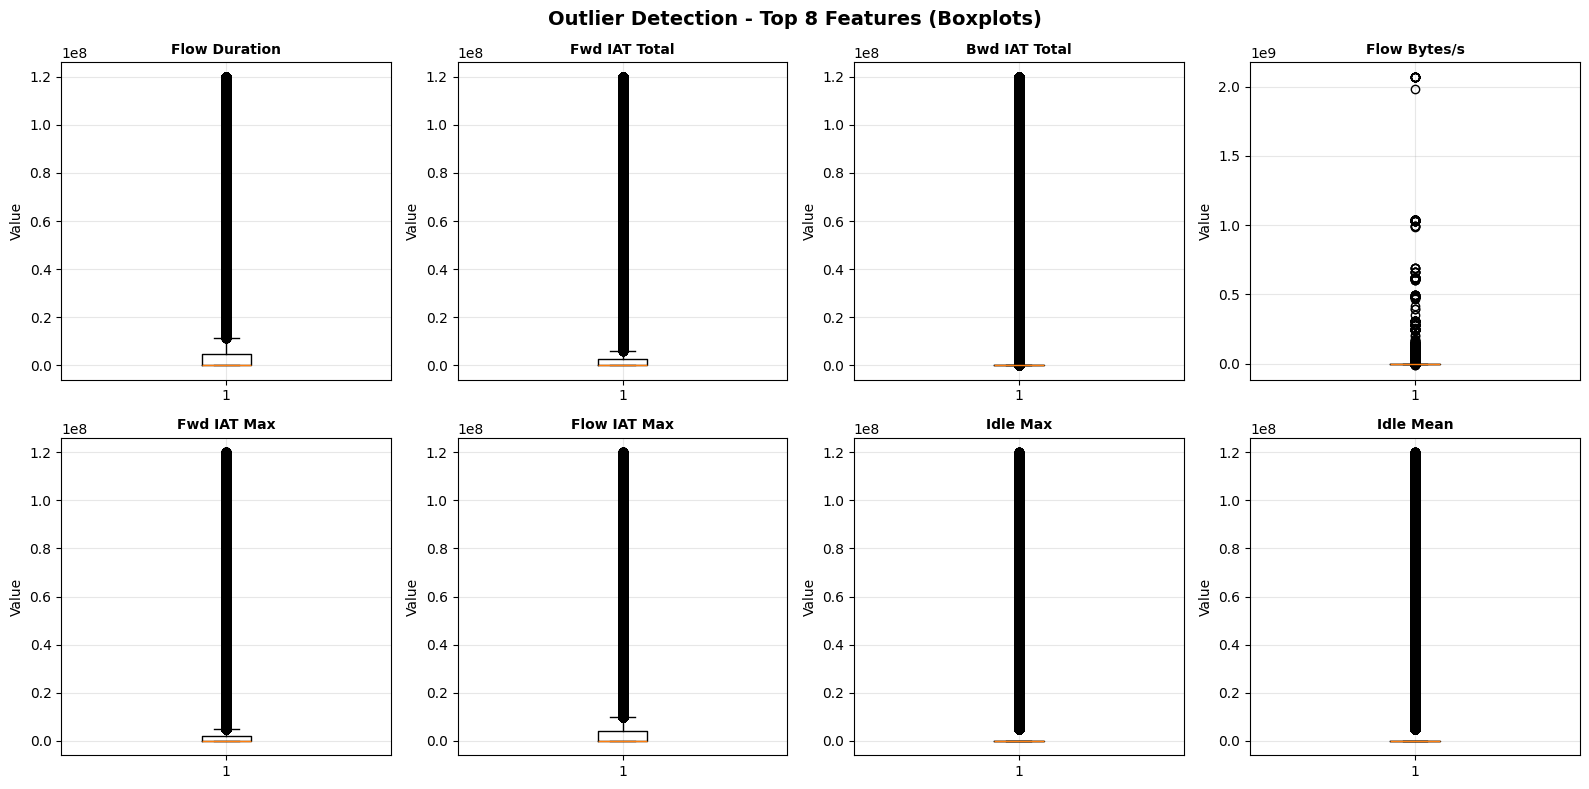

✓ Boxplots generated
Note: Extreme values may be legitimate attack patterns in intrusion data


In [41]:
top_8_features = df[numeric_cols].var().nlargest(8).index.tolist()

fig, axes = plt.subplots(2, 4, figsize=(16, 8))
axes = axes.flatten()

for idx, col in enumerate(top_8_features):
    axes[idx].boxplot(df[col].dropna(), vert=True)
    axes[idx].set_title(f'{col[:20]}', fontsize=10, fontweight='bold')
    axes[idx].set_ylabel('Value')
    axes[idx].grid(True, alpha=0.3)

fig.suptitle('Outlier Detection - Top 8 Features (Boxplots)', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.show()

print('✓ Boxplots generated')
print('Note: Extreme values may be legitimate attack patterns in intrusion data')


### Step 3A: Prepare features and encode target
This cell converts the target label to numeric classes and builds the initial numeric feature matrix used for downstream selection and modeling.

In [42]:
le = LabelEncoder()
y = le.fit_transform(df['Label'])

numeric_cols = df.select_dtypes(include=[np.number]).columns.tolist()
X = df[numeric_cols].copy()

print('Encoded target classes:', len(le.classes_))
print('Initial numeric features:', len(numeric_cols))

Encoded target classes: 15
Initial numeric features: 78


### Step 3B: Remove low-variance features


This cell removes near-constant features using `VarianceThreshold(0.001)`. Features with very low variance usually carry little discriminative information, so dropping them reduces noise and can speed up downstream feature selection and model training.

In [43]:
var_selector = VarianceThreshold(threshold=0.001)
X = pd.DataFrame(
    var_selector.fit_transform(X),
    columns=X.columns[var_selector.get_support()]
)

print('After variance filtering:', X.shape[1])

After variance filtering: 66


### Step 3C: Select top features with SelectKBest (tuned `k`)

In this step, `k` is selected using hyperparameter tuning instead of a fixed value.

How it works in this notebook:
- Build a pipeline: `SelectKBest(f_classif)` + a lightweight `RandomForestClassifier`.
- Run `GridSearchCV` with `StratifiedKFold` to test candidate `k` values.
- Choose `k` with the best cross-validated weighted F1 score.
- Refit `SelectKBest` with the chosen `k` and keep only selected features.

This makes feature-count selection more data-driven while keeping runtime manageable.

In [44]:
max_k = min(40, X.shape[1])
candidate_ks = sorted(set([k for k in [10, 20, 30, 40, max_k] if 1 <= k <= X.shape[1]]))

tuning_pipeline = Pipeline([
    ('select', SelectKBest(score_func=f_classif)),
    ('clf', RandomForestClassifier(
        n_estimators=80,
        max_depth=12,
        min_samples_split=5,
        min_samples_leaf=2,
        class_weight='balanced_subsample',
        random_state=42,
        n_jobs=-1
    ))
])

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=42)
param_grid = {'select__k': candidate_ks}

grid = GridSearchCV(
    estimator=tuning_pipeline,
    param_grid=param_grid,
    scoring='f1_weighted',
    cv=cv,
    n_jobs=-1
)
grid.fit(X, y)
best_k = grid.best_params_['select__k']
k_selector = SelectKBest(f_classif, k=best_k)
X_kbest = k_selector.fit_transform(X, y)
selected_features = X.columns[k_selector.get_support()].tolist()
X = pd.DataFrame(X_kbest, columns=selected_features)

print('Candidate k values:', candidate_ks)
print('Best k (CV):', best_k)
print('Selected top features:', len(selected_features))
print('After SelectKBest:', X.shape[1])

Candidate k values: [10, 20, 30, 40]
Best k (CV): 40
Selected top features: 40
After SelectKBest: 40


### Step 3D: Apply log transform to highly skewed features

This step reduces extreme right-skew in numeric features using `log1p` (`log(1+x)`) before splitting and scaling. It is applied only to features that are non-negative and sufficiently skewed.

In [45]:
skewness = X.skew(numeric_only=True)
candidate_log_features = skewness[skewness > 1.0].index.tolist()
log_features = [col for col in candidate_log_features if X[col].min() >= 0]

if log_features:
    X[log_features] = np.log1p(X[log_features])
    print(f'Applied log1p transform to {len(log_features)} skewed non-negative features.')
    print('Sample transformed features:', log_features[:10])
else:
    print('No suitable features found for log1p transform (skew > 1 and non-negative).')

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)
print('Train shape:', X_train.shape, '| Test shape:', X_test.shape)

scaler = RobustScaler()
X_train_scaled = pd.DataFrame(scaler.fit_transform(X_train), columns=selected_features)
X_test_scaled = pd.DataFrame(scaler.transform(X_test), columns=selected_features)

Applied log1p transform to 33 skewed non-negative features.
Sample transformed features: ['Destination Port', 'Bwd Packet Length Max', 'Bwd Packet Length Min', 'Bwd Packet Length Mean', 'Bwd Packet Length Std', 'Flow IAT Std', 'Fwd IAT Total', 'Fwd IAT Mean', 'Fwd IAT Std', 'Fwd IAT Max']
Train shape: (215286, 40) | Test shape: (53822, 40)


### Step 3E: Handle class imbalance with adaptive SMOTE

Synthetic Minority Over-sampling Technique, handles class imbalance in the training set using adaptive SMOTE. It checks the smallest class size, chooses `k_neighbors` safely (`min(5, min_class_size - 1)`), and oversamples minority classes to balance training data. If any class has fewer than 2 samples, it skips SMOTE to avoid runtime errors and keeps the original training split.

In [46]:
from imblearn.over_sampling import SMOTE
from imblearn.combine import SMOTETomek
from imblearn.under_sampling import RandomUnderSampler

class_counts = Counter(y_train)
print('Class distribution before balancing:', class_counts)

label_to_id = {label: idx for idx, label in enumerate(le.classes_)}
id_to_label = {idx: label for label, idx in label_to_id.items()}
benign_id = label_to_id.get('BENIGN')

# ----- 1) Fixed thresholds by class name (editable) -----
# Only classes found in your current labels will be used.
# Values are target counts AFTER oversampling.
fixed_targets_by_name = {
    'Heartbleed': 2_000,
    'Infiltration': 6_000,
    'Bot': 8_000,
    'FTP-Patator': 10_000,
    'SSH-Patator': 10_000,
    'Web Attack': 12_000,
    'DoS': 15_000,
    'DDoS': 20_000,
    'PortScan': 20_000
}

# Build per-class target dict from class names
smote_targets = {}
for class_id, count in class_counts.items():
    if class_id == benign_id or count < 2:
        continue

    class_name = id_to_label[class_id]
    matched_target = None

    for name_key, target_value in fixed_targets_by_name.items():
        if name_key in class_name:
            matched_target = target_value
            break

    if matched_target is not None and matched_target > count:
        smote_targets[class_id] = matched_target

if len(smote_targets) > 0:
    print('Using fixed SMOTE targets:')
    for cid, target in smote_targets.items():
        print(f"  {id_to_label[cid]}: {class_counts[cid]} -> {target}")

    min_target_class_size = min(class_counts[cid] for cid in smote_targets)
    k_neighbors = min(5, min_target_class_size - 1)

    smt = SMOTETomek(
        random_state=42,
        smote=SMOTE(
            sampling_strategy=smote_targets,
            random_state=42,
            k_neighbors=k_neighbors
        )
    )
    X_train_balanced, y_train_balanced = smt.fit_resample(X_train_scaled, y_train)
    print(f'Applied SMOTETomek with fixed targets (k_neighbors={k_neighbors})')
else:
    X_train_balanced = X_train_scaled.copy()
    y_train_balanced = y_train.copy()
    print('Skipped SMOTETomek: no eligible class matched fixed targets and count>=2.')

# ----- 2) BENIGN undersampling threshold (editable) -----
if benign_id is not None:
    post_counts = Counter(y_train_balanced)
    benign_count = post_counts.get(benign_id, 0)
    benign_target = min(120_000, benign_count)

    if benign_target < benign_count:
        rus = RandomUnderSampler(
            sampling_strategy={benign_id: benign_target},
            random_state=42
        )
        X_train_balanced, y_train_balanced = rus.fit_resample(X_train_balanced, y_train_balanced)
        print(f'Applied BENIGN undersampling: {benign_count:,} -> {benign_target:,}')

X_train_balanced = pd.DataFrame(X_train_balanced, columns=selected_features)
print('Final class distribution:', Counter(y_train_balanced))

Class distribution before balancing: Counter({np.int64(0): 176268, np.int64(4): 14197, np.int64(10): 11633, np.int64(2): 10333, np.int64(3): 802, np.int64(7): 521, np.int64(6): 436, np.int64(5): 426, np.int64(11): 332, np.int64(1): 145, np.int64(12): 133, np.int64(14): 53, np.int64(9): 3, np.int64(13): 2, np.int64(8): 2})
Using fixed SMOTE targets:
  DoS Hulk: 14197 -> 15000
  PortScan: 11633 -> 20000
  Bot: 145 -> 8000
  DDoS: 10333 -> 15000
  FTP-Patator: 521 -> 10000
  DoS GoldenEye: 802 -> 15000
  DoS Slowhttptest: 426 -> 15000
  DoS slowloris: 436 -> 15000
  SSH-Patator: 332 -> 10000
  Web Attack � XSS: 53 -> 12000
  Web Attack � Brute Force: 133 -> 12000
  Infiltration: 3 -> 6000
  Web Attack � Sql Injection: 2 -> 12000
  Heartbleed: 2 -> 2000
Applied SMOTETomek with fixed targets (k_neighbors=1)
Applied BENIGN undersampling: 176,098 -> 120,000
Final class distribution: Counter({np.int64(0): 120000, np.int64(10): 19966, np.int64(2): 14994, np.int64(3): 14960, np.int64(5): 14958, 

## Step 4: Train model on balanced training set

In [55]:
print('\n' + '='*60)
print('STEP 4: MODEL TRAINING')
print('='*60)

models = {
    # 'Logistic Regression': LogisticRegression(max_iter=200, random_state=42, class_weight='balanced'),
    'Random Forest': RandomForestClassifier(
        n_estimators=100, max_depth=20, min_samples_split=5, min_samples_leaf=2,
        random_state=42, n_jobs=-1, class_weight='balanced'
    ),
    # 'Gradient Boosting': GradientBoostingClassifier(
    #     n_estimators=50, max_depth=7, learning_rate=0.1, subsample=0.8, random_state=42
    # ),
    'XGBoost': XGBClassifier(
        n_estimators=100, max_depth=7, learning_rate=0.1, subsample=0.8,
        colsample_bytree=0.8, random_state=42, eval_metric='logloss', n_jobs=-1
    )
}

trained_models = {}
model_scores = {}
train_scores = {}
test_scores = {}

for name, model in models.items():
    print(f'Training {name}...')
    model.fit(X_train_balanced, y_train_balanced)

    train_score = model.score(X_train_balanced, y_train_balanced)
    test_score = model.score(X_test_scaled, y_test)

    y_pred = model.predict(X_test_scaled)
    weighted_f1 = f1_score(y_test, y_pred, average='weighted', zero_division=0)

    trained_models[name] = model
    train_scores[name] = train_score
    test_scores[name] = test_score
    model_scores[name] = weighted_f1

    print(f'  Train score: {train_score:.4f}')
    print(f'  Test score : {test_score:.4f}')
    print(f'  Weighted F1: {weighted_f1:.4f}')

best_model_name = max(model_scores, key=model_scores.get)
best_model = trained_models[best_model_name]

print('\nModel comparison:')
for name in sorted(model_scores, key=model_scores.get, reverse=True):
    print(
        f"  {name:20s} | Train: {train_scores[name]:.4f} | "
        f"Test: {test_scores[name]:.4f} | Weighted F1: {model_scores[name]:.4f}"
    )

print(f'\nSelected best model: {best_model_name}')
print(f'Training samples used: {len(y_train_balanced):,}')


STEP 4: MODEL TRAINING
Training Random Forest...
  Train score: 0.9972
  Test score : 0.9956
  Weighted F1: 0.9963
Training XGBoost...
  Train score: 0.9991
  Test score : 0.9980
  Weighted F1: 0.9981

Model comparison:
  XGBoost              | Train: 0.9991 | Test: 0.9980 | Weighted F1: 0.9981
  Random Forest        | Train: 0.9972 | Test: 0.9956 | Weighted F1: 0.9963

Selected best model: XGBoost
Training samples used: 286,752


## Step 5: Evaluate the best model


Classification Report
                            precision    recall  f1-score   support

                    BENIGN     0.9996    0.9984    0.9990     44067
                       Bot     0.5152    0.9444    0.6667        36
                      DDoS     1.0000    0.9985    0.9992      2584
             DoS GoldenEye     0.9950    1.0000    0.9975       200
                  DoS Hulk     0.9961    0.9975    0.9968      3550
          DoS Slowhttptest     0.9630    0.9811    0.9720       106
             DoS slowloris     0.9909    1.0000    0.9954       109
               FTP-Patator     0.9923    0.9923    0.9923       130
              Infiltration     0.0000    0.0000    0.0000         1
                  PortScan     0.9945    0.9997    0.9971      2909
               SSH-Patator     0.9762    0.9880    0.9820        83
  Web Attack � Brute Force     0.7353    0.7576    0.7463        33
Web Attack � Sql Injection     1.0000    1.0000    1.0000         1
          Web Attack � X

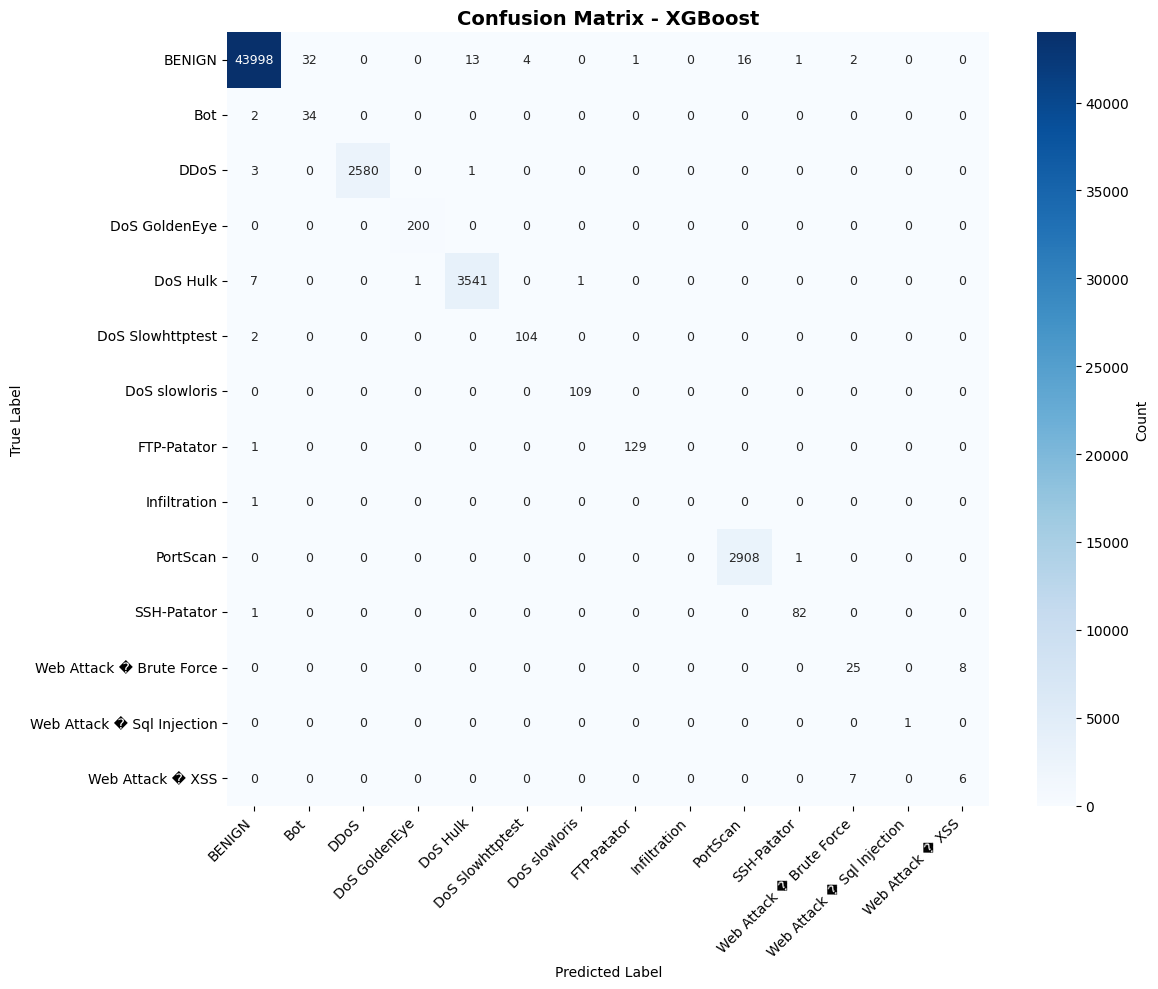


Top 10 features:
                   feature  importance
3    Bwd Packet Length Min    0.075072
28          ACK Flag Count    0.069926
27          PSH Flag Count    0.061300
38                Idle Max    0.054615
0         Destination Port    0.045387
30     Average Packet Size    0.041238
29          URG Flag Count    0.041096
37                Idle Std    0.039706
22       Max Packet Length    0.039687
4   Bwd Packet Length Mean    0.037724


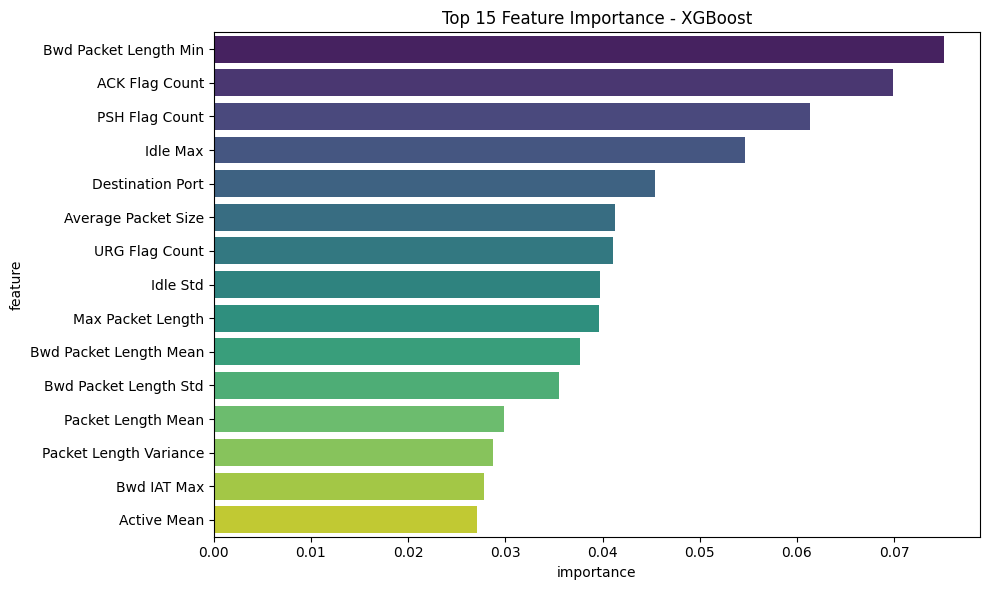

In [54]:
y_test_pred = best_model.predict(X_test_scaled)
y_test_proba = best_model.predict_proba(X_test_scaled)

present_labels = np.unique(np.concatenate([y_test, y_test_pred]))
present_label_names = le.inverse_transform(present_labels)

print('\nClassification Report')
print(
    classification_report(
        y_test,
        y_test_pred,
        labels=present_labels,
        target_names=present_label_names,
        digits=4,
        zero_division=0
    )
)

accuracy = accuracy_score(y_test, y_test_pred)
precision = precision_score(y_test, y_test_pred, average='weighted', zero_division=0)
recall = recall_score(y_test, y_test_pred, average='weighted', zero_division=0)
f1 = f1_score(y_test, y_test_pred, average='weighted', zero_division=0)

print(f'Accuracy : {accuracy:.4f}')
print(f'Precision: {precision:.4f}')
print(f'Recall   : {recall:.4f}')
print(f'F1-score : {f1:.4f}')

try:
    if len(np.unique(y_test)) > 2:
        roc_auc = roc_auc_score(y_test, y_test_proba, multi_class='ovr', average='macro')
    else:
        roc_auc = roc_auc_score(y_test, y_test_proba[:, 1])
    print(f'ROC-AUC  : {roc_auc:.4f}')
except Exception:
    print('ROC-AUC  : N/A')

cm = confusion_matrix(y_test, y_test_pred, labels=present_labels)
plt.figure(figsize=(12, 10))
sns.heatmap(
    cm, annot=True, fmt='d', cmap='Blues',
    xticklabels=present_label_names, yticklabels=present_label_names,
    cbar_kws={'label': 'Count'}, annot_kws={'size': 9}
)
plt.title(f'Confusion Matrix - {best_model_name}', fontsize=14, fontweight='bold')
plt.ylabel('True Label')
plt.xlabel('Predicted Label')
plt.xticks(rotation=45, ha='right')
plt.yticks(rotation=0)
plt.tight_layout()
plt.show()

if hasattr(best_model, 'feature_importances_'):
    feature_importance_df = pd.DataFrame({
        'feature': X_test_scaled.columns.tolist(),
        'importance': best_model.feature_importances_
    }).sort_values('importance', ascending=False)

    print('\nTop 10 features:')
    print(feature_importance_df.head(10))

    plt.figure(figsize=(10, 6))
    sns.barplot(data=feature_importance_df.head(15), x='importance', y='feature', palette='viridis')
    plt.title(f'Top 15 Feature Importance - {best_model_name}')
    plt.tight_layout()
    plt.show()

## Step 6: Save artifacts and create prediction helper

### Step 6A: Save model artifacts and define inference helper
This cell saves the trained model pipeline components (`model`, `scaler`, `label_encoder`, `selected_features`) and defines a reusable `predict_flow` function for new samples.

In [ ]:
artifacts = {
    'model': best_model,
    'scaler': scaler,
    'label_encoder': le,
    'selected_features': selected_features
}

output_path = 'network_intrusion_model.pkl'
with open(output_path, 'wb') as f:
    pickle.dump(artifacts, f)
print(f"Model artifacts saved to: {output_path}")

def predict_flow(flow_data_dict, model_path='network_intrusion_model.pkl'):
    with open(model_path, 'rb') as f:
        artifacts = pickle.load(f)

    model = artifacts['model']
    scaler_obj = artifacts['scaler']
    label_encoder = artifacts['label_encoder']
    features = artifacts['selected_features']

    flow_df = pd.DataFrame([flow_data_dict])
    flow_scaled = scaler_obj.transform(flow_df[features])

    pred_class = model.predict(flow_scaled)[0]
    pred_proba = model.predict_proba(flow_scaled)[0]

    return {
        'prediction': label_encoder.inverse_transform([pred_class])[0],
        'confidence': float(pred_proba.max()),
        'probabilities': {
            label_encoder.inverse_transform([i])[0]: float(p)
            for i, p in enumerate(pred_proba)
        }
    }

print('Prediction helper ready: predict_flow(flow_data_dict)')

Model artifacts saved to: network_intrusion_model.pkl
Prediction helper ready: predict_flow(flow_data_dict)
